# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves. Thanks [Yandex Data School Analysis](https://github.com/yandexdataschool/Practical_DL/blob/fall21/week03_convnets/seminar_pytorch.ipynb) for this work!

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

![image](https://github.com/yandexdataschool/Practical_DL/raw/fall21/week03_convnets/cifar10.jpg)

In [20]:
# when running in colab, un-comment this
# !wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py

In [21]:
import numpy as np
from torchvision.datasets import CIFAR10

data_root = "./cifar_data"
full_train_dataset = CIFAR10(root=data_root, train=True, download=True)
full_test_dataset = CIFAR10(root=data_root, train=False, download=True)

X_full = full_train_dataset.data.astype("float32") / 255.0
y_full = np.array(full_train_dataset.targets, dtype=np.int64)
X_test = full_test_dataset.data.astype("float32") / 255.0
y_test = np.array(full_test_dataset.targets, dtype=np.int64)

rng = np.random.RandomState(42)
indices = rng.permutation(len(X_full))
val_size = 5000
val_indices = indices[:val_size]
train_indices = indices[val_size:]

X_train = np.transpose(X_full[train_indices], (0, 3, 1, 2))
y_train = y_full[train_indices]
X_val = np.transpose(X_full[val_indices], (0, 3, 1, 2))
y_val = y_full[val_indices]
X_test = np.transpose(X_test, (0, 3, 1, 2))

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)


train: (45000, 3, 32, 32) (45000,)
val:   (5000, 3, 32, 32) (5000,)
test:  (10000, 3, 32, 32) (10000,)


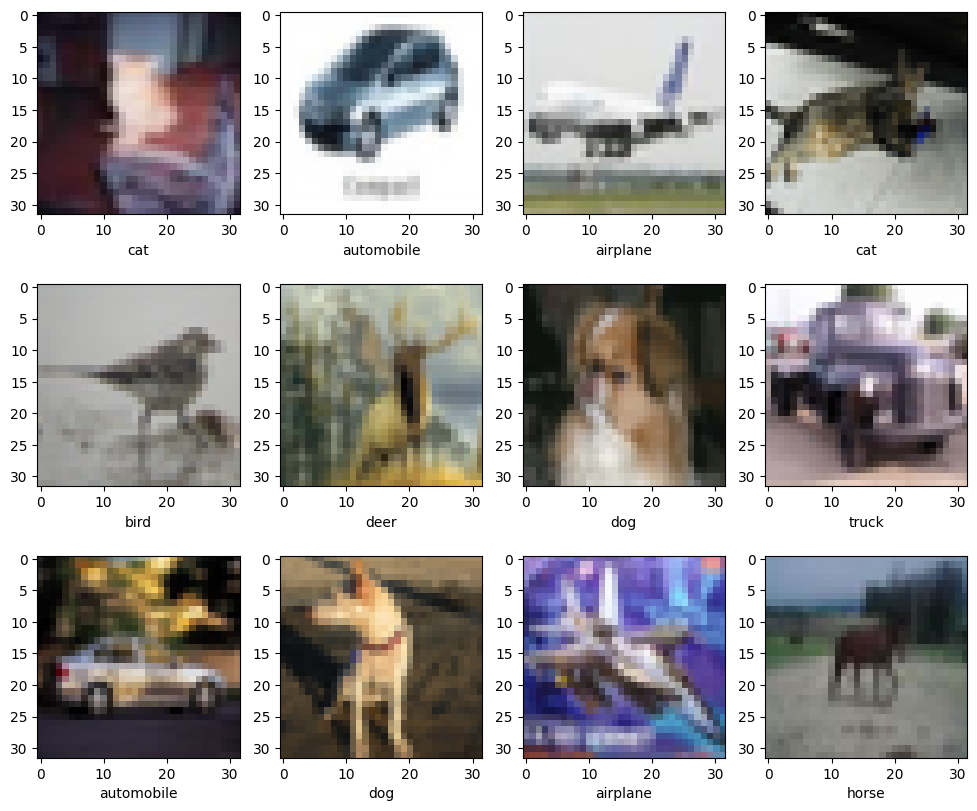

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

In [23]:
import torch, torch.nn as nn
import torch.nn.functional as F

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

Let's start with a dense network for our baseline:

In [24]:
model = nn.Sequential()

# reshape from "images" to flat vectors
model.add_module('flatten', Flatten())

# dense "head"
model.add_module('dense1', nn.Linear(3 * 32 * 32, 64))
model.add_module('dense1_relu', nn.ReLU())
model.add_module('dense2_logits', nn.Linear(64, 10)) # logits for 10 classes

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [25]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [26]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.2607, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [27]:
# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [28]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

In [29]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())
        
    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))

    
    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 1.108s
  training loss (in-iteration): 	2.028929
  validation accuracy: 			32.72 %
Epoch 2 of 100 took 1.107s
  training loss (in-iteration): 	1.848483
  validation accuracy: 			36.16 %
Epoch 3 of 100 took 1.052s
  training loss (in-iteration): 	1.773750
  validation accuracy: 			36.70 %
Epoch 4 of 100 took 1.068s
  training loss (in-iteration): 	1.720614
  validation accuracy: 			39.52 %
Epoch 5 of 100 took 1.098s
  training loss (in-iteration): 	1.679606
  validation accuracy: 			40.00 %
Epoch 6 of 100 took 1.062s
  training loss (in-iteration): 	1.645717
  validation accuracy: 			41.20 %
Epoch 7 of 100 took 1.065s
  training loss (in-iteration): 	1.617746
  validation accuracy: 			42.32 %
Epoch 8 of 100 took 1.077s
  training loss (in-iteration): 	1.596003
  validation accuracy: 			41.70 %
Epoch 9 of 100 took 1.085s
  training loss (in-iteration): 	1.577016
  validation accuracy: 			43.76 %
Epoch 10 of 100 took 1.101s
  training loss (in-iteration): 	1.556319
  v

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [30]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)
    
print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		51.70 %
Achievement unlocked: 60lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.




```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [31]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465), dtype=np.float32)
stds = np.array((0.2023, 0.1994, 0.2010), dtype=np.float32)

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])


In [32]:
from torchvision.datasets import CIFAR10

train_aug_dataset = CIFAR10("./cifar_data/", train=True, download=False, transform=transform_augment)
train_batch_gen = torch.utils.data.DataLoader(
    torch.utils.data.Subset(train_aug_dataset, train_indices),
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


X: <class 'torch.Tensor'> torch.Size([128, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([128])


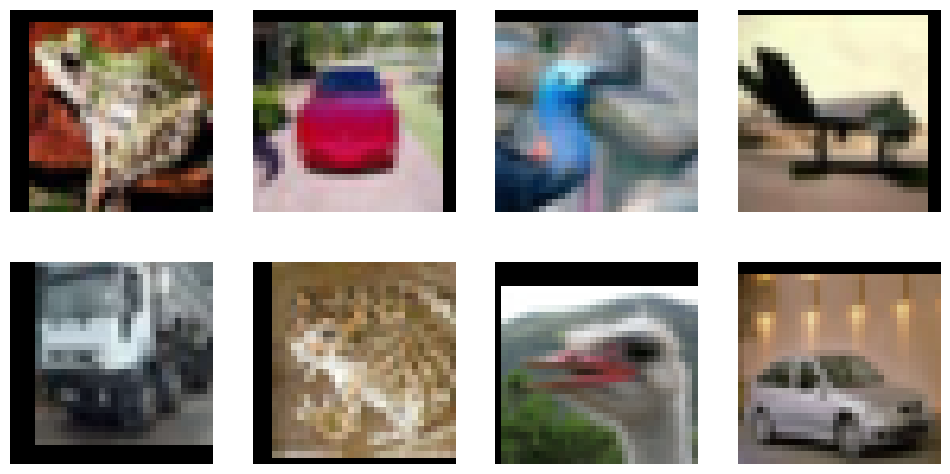

In [33]:
plt.figure(figsize=(12, 6))
for x_batch, y_batch in train_batch_gen:
    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)

    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.clip(img.transpose([1, 2, 0]) * stds + means, 0, 1))
        plt.axis('off')

    break


When testing, we don't need random crops, just normalize with same statistics.

In [34]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

val_dataset = CIFAR10("./cifar_data/", train=True, download=False, transform=transform_test)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(val_dataset, val_indices),
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_dataset = CIFAR10("./cifar_data/", train=False, download=False, transform=transform_test)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


In [35]:
import copy
import random
from torch.utils.data import DataLoader, TensorDataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

means_4d = means.reshape(1, 3, 1, 1)
stds_4d = stds.reshape(1, 3, 1, 1)


def normalize_split(X):
    return ((X - means_4d) / stds_4d).astype(np.float32)


def make_loader(X, y, batch_size=128, shuffle=False):
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y.astype(np.int64)),
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


X_train_norm = normalize_split(X_train)
X_val_norm = normalize_split(X_val)
X_test_norm = normalize_split(X_test)

plain_train_loader = make_loader(X_train_norm, y_train, batch_size=128, shuffle=True)
plain_val_loader = make_loader(X_val_norm, y_val, batch_size=256, shuffle=False)
plain_test_loader = make_loader(X_test_norm, y_test, batch_size=256, shuffle=False)


def build_small_conv_net():
    return nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(16 * 16 * 16, 100),
        nn.ReLU(inplace=True),
        nn.Dropout(0.10),
        nn.Linear(100, 10),
    )


def build_small_conv_bn_net():
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(32 * 16 * 16, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.15),
        nn.Linear(128, 10),
    )


class BetterCIFARNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(x_batch)
        loss = F.cross_entropy(logits, y_batch)

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_samples += y_batch.size(0)

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


def train_model(model, train_loader, val_loader, optimizer, device,
                epochs=20, scheduler=None, early_stopping=5):
    model.to(device)
    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    history = []
    patience = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_seen = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_batch)
            loss = F.cross_entropy(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y_batch.size(0)
            running_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_seen += y_batch.size(0)

        train_metrics = {
            "loss": running_loss / total_seen,
            "accuracy": running_correct / total_seen,
        }
        val_metrics = evaluate_model(model, val_loader, device)

        if scheduler is not None:
            scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        })

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train acc {train_metrics['accuracy'] * 100:.2f}% | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val acc {val_metrics['accuracy'] * 100:.2f}%"
        )

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience >= early_stopping:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return history


def plot_history(history, title):
    epochs = [row["epoch"] for row in history]
    train_acc = [row["train_accuracy"] for row in history]
    val_acc = [row["val_accuracy"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row["val_loss"] for row in history]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train")
    plt.plot(epochs, val_loss, label="val")
    plt.title(f"{title}: loss")
    plt.xlabel("epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="train")
    plt.plot(epochs, val_acc, label="val")
    plt.title(f"{title}: accuracy")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()


device: cuda


epoch 01 | train loss 1.5250 | train acc 45.61% | val loss 1.3012 | val acc 54.22%
epoch 02 | train loss 1.2251 | train acc 56.68% | val loss 1.1754 | val acc 58.24%
epoch 03 | train loss 1.1082 | train acc 60.57% | val loss 1.1122 | val acc 60.10%
epoch 04 | train loss 1.0170 | train acc 63.96% | val loss 1.0757 | val acc 62.38%
epoch 05 | train loss 0.9506 | train acc 66.40% | val loss 1.0605 | val acc 62.00%
epoch 06 | train loss 0.8928 | train acc 68.32% | val loss 1.0285 | val acc 63.34%
epoch 07 | train loss 0.8460 | train acc 69.67% | val loss 1.0318 | val acc 63.60%
epoch 08 | train loss 0.7972 | train acc 71.81% | val loss 1.0178 | val acc 64.38%
epoch 09 | train loss 0.7566 | train acc 73.08% | val loss 1.0341 | val acc 64.76%
epoch 10 | train loss 0.7237 | train acc 74.06% | val loss 1.0434 | val acc 64.66%
epoch 11 | train loss 0.6915 | train acc 75.32% | val loss 1.0252 | val acc 64.84%
epoch 12 | train loss 0.6536 | train acc 76.56% | val loss 1.0156 | val acc 65.84%
epoc

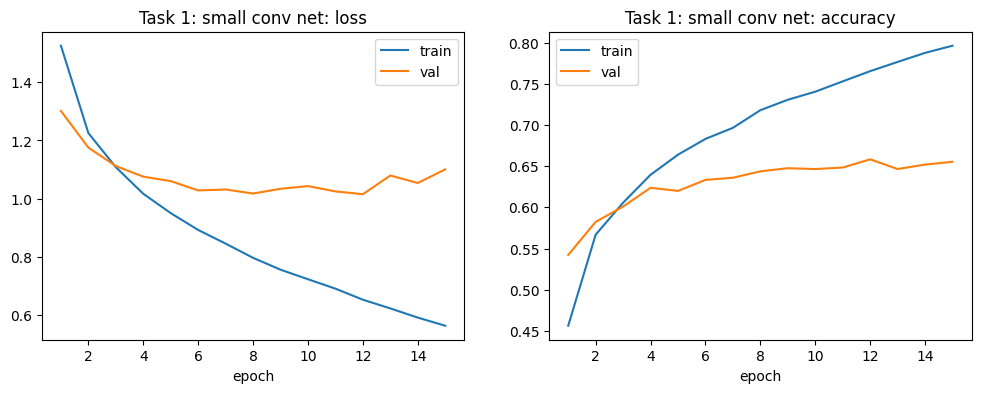

Task 1 validation: {'loss': 1.0155700159072876, 'accuracy': 0.6584}
Task 1 test: {'loss': 1.021040933227539, 'accuracy': 0.658}


In [36]:
small_conv_model = build_small_conv_net().to(device)
small_conv_optimizer = torch.optim.Adam(small_conv_model.parameters(), lr=1e-3)

small_conv_history = train_model(
    small_conv_model,
    plain_train_loader,
    plain_val_loader,
    small_conv_optimizer,
    device=device,
    epochs=15,
    early_stopping=4,
)

plot_history(small_conv_history, "Task 1: small conv net")
small_conv_val = evaluate_model(small_conv_model, plain_val_loader, device)
small_conv_test = evaluate_model(small_conv_model, plain_test_loader, device)
print("Task 1 validation:", small_conv_val)
print("Task 1 test:", small_conv_test)


epoch 01 | train loss 1.3365 | train acc 52.54% | val loss 1.1575 | val acc 57.88%
epoch 02 | train loss 1.0022 | train acc 64.53% | val loss 1.0630 | val acc 62.12%
epoch 03 | train loss 0.8428 | train acc 70.55% | val loss 0.9348 | val acc 66.94%
epoch 04 | train loss 0.7314 | train acc 74.42% | val loss 0.9364 | val acc 66.52%
epoch 05 | train loss 0.6378 | train acc 77.75% | val loss 0.9588 | val acc 66.46%
epoch 06 | train loss 0.5506 | train acc 80.98% | val loss 0.9660 | val acc 67.06%
epoch 07 | train loss 0.4822 | train acc 83.32% | val loss 0.9734 | val acc 67.92%
epoch 08 | train loss 0.4102 | train acc 86.08% | val loss 1.0257 | val acc 66.86%
epoch 09 | train loss 0.3592 | train acc 87.70% | val loss 1.0545 | val acc 67.72%
epoch 10 | train loss 0.3142 | train acc 89.33% | val loss 1.0892 | val acc 67.14%
epoch 11 | train loss 0.2744 | train acc 90.81% | val loss 1.1535 | val acc 66.80%
epoch 12 | train loss 0.2461 | train acc 91.78% | val loss 1.1737 | val acc 67.00%
Earl

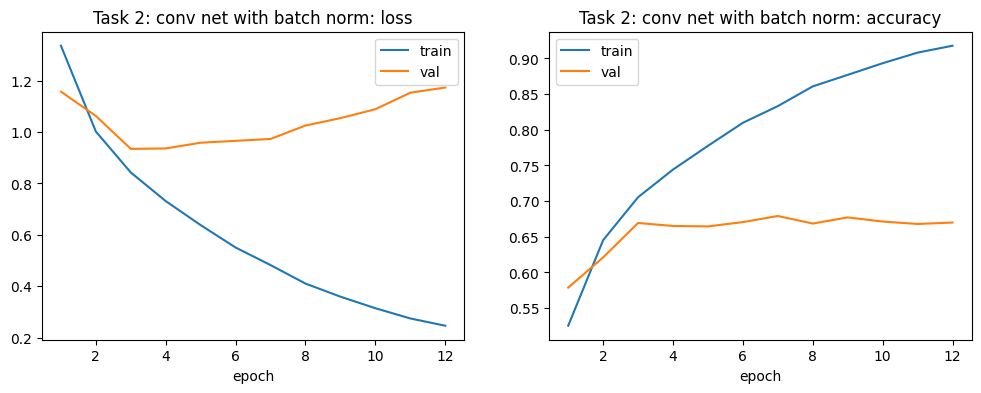

Task 2 validation: {'loss': 0.9734007484436035, 'accuracy': 0.6792}
Task 2 test: {'loss': 0.997674337387085, 'accuracy': 0.674}


In [37]:
small_conv_bn_model = build_small_conv_bn_net().to(device)
small_conv_bn_optimizer = torch.optim.Adam(small_conv_bn_model.parameters(), lr=1e-3)

small_conv_bn_history = train_model(
    small_conv_bn_model,
    plain_train_loader,
    plain_val_loader,
    small_conv_bn_optimizer,
    device=device,
    epochs=20,
    early_stopping=5,
)

plot_history(small_conv_bn_history, "Task 2: conv net with batch norm")
small_conv_bn_val = evaluate_model(small_conv_bn_model, plain_val_loader, device)
small_conv_bn_test = evaluate_model(small_conv_bn_model, plain_test_loader, device)
print("Task 2 validation:", small_conv_bn_val)
print("Task 2 test:", small_conv_bn_test)


# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.
 
## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons, 
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.
 
   
### Data augmemntation
   * getting 5x as large dataset for free is a great 
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


epoch 01 | train loss 1.4303 | train acc 47.16% | val loss 1.2661 | val acc 54.10%
epoch 02 | train loss 1.0331 | train acc 63.13% | val loss 1.1388 | val acc 59.24%
epoch 03 | train loss 0.8742 | train acc 68.88% | val loss 0.9456 | val acc 67.86%
epoch 04 | train loss 0.7645 | train acc 73.05% | val loss 0.7481 | val acc 73.30%
epoch 05 | train loss 0.6907 | train acc 75.80% | val loss 0.6800 | val acc 76.34%
epoch 06 | train loss 0.6357 | train acc 78.05% | val loss 0.6651 | val acc 77.72%
epoch 07 | train loss 0.5914 | train acc 79.71% | val loss 0.6031 | val acc 78.62%
epoch 08 | train loss 0.5504 | train acc 81.06% | val loss 0.5441 | val acc 81.50%
epoch 09 | train loss 0.5132 | train acc 82.39% | val loss 0.5301 | val acc 82.06%
epoch 10 | train loss 0.4904 | train acc 83.19% | val loss 0.5308 | val acc 82.62%
epoch 11 | train loss 0.4646 | train acc 84.08% | val loss 0.5334 | val acc 82.32%
epoch 12 | train loss 0.4408 | train acc 84.90% | val loss 0.4994 | val acc 83.48%
epoc

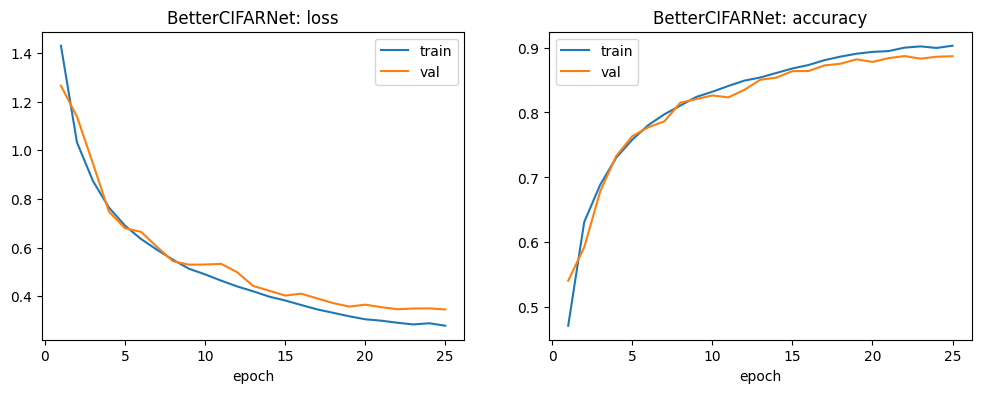

Validation: {'loss': 0.34700800585746766, 'accuracy': 0.8868}
Test: {'loss': 0.3665164155960083, 'accuracy': 0.8764}


{'task1_val_acc': 0.6584,
 'task1_test_acc': 0.658,
 'task2_val_acc': 0.6792,
 'task2_test_acc': 0.674,
 'homework_val_acc': 0.8868,
 'homework_test_acc': 0.8764}

In [38]:
better_model = BetterCIFARNet().to(device)
better_optimizer = torch.optim.AdamW(
    better_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)
better_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    better_optimizer,
    T_max=25,
)

better_history = train_model(
    better_model,
    train_batch_gen,
    val_loader,
    better_optimizer,
    device=device,
    epochs=25,
    scheduler=better_scheduler,
    early_stopping=7,
)

plot_history(better_history, "BetterCIFARNet")
better_val = evaluate_model(better_model, val_loader, device)
better_test = evaluate_model(better_model, test_loader, device)
print("Validation:", better_val)
print("Test:", better_test)

results = {
    "task1_val_acc": small_conv_val["accuracy"],
    "task1_test_acc": small_conv_test["accuracy"],
    "task2_val_acc": small_conv_bn_val["accuracy"],
    "task2_test_acc": small_conv_bn_test["accuracy"],
    "homework_val_acc": better_val["accuracy"],
    "homework_test_acc": better_test["accuracy"],
}
results


# Iteration improvement path

Baseline dense network
Result: about 51.7% test.
Conclusion: fully connected model is too weak for CIFAR-10 spatial structure.

Small convolutional network
Change: replaced dense baseline with one conv + pooling + MLP head.
Result: about 65.8% test.
Conclusion: convolution helps a lot because it uses local spatial patterns.

Conv net with batch normalization
Change: added batch norm after conv and dense layers.
Result: about 67.4% test.
Conclusion: optimization became more stable and accuracy improved.

Stronger CNN with augmentation
Change: deeper conv blocks, batch norm, dropout, AdamW, cosine LR, random crop + horizontal flip.
Result: about 87.6% test.
Conclusion: depth + normalization + augmentation gave the main gain.